# Video 4 — frames → PIVlab → centro del vórtice → perfiles de velocidad

Este notebook está armado para hacer el análisis en este orden:

1. **Separar `video4_glicerina20.MOV` en frames PNG** y guardarlos en una carpeta del Escritorio.
2. Procesar esos frames en **PIVlab** y exportar el resultado como `.mat`.
3. Volver a este notebook, indicar la ruta del `.mat` y **seguir el centro del vórtice campo por campo**.
4. Decidir cuantitativamente si el centro puede considerarse prácticamente fijo.
5. Solo si esa aproximación es razonable, usar un **centro fijo** para calcular:
   - campo de velocidad temporalmente promediado;
   - \(v_r(r)\);
   - \(v_\theta(r)\);
   - promedio espacial en coronas;
   - promedio temporal de esos perfiles;
   - dispersión temporal e incertidumbre de la media.

La lógica de lectura del `.mat` y de determinación del centro sigue el análisis que ya venías usando con `resultslist`.

> **Importante:** primero corré solamente la sección 1. Después hacé el PIV en PIVlab. Recién entonces continuá desde la sección 2.

In [ ]:
# Si alguna librería te falta, corré esta celda UNA sola vez:
# %pip install opencv-python numpy pandas matplotlib scipy h5py

In [1]:
from pathlib import Path
import json
import math

import cv2
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import least_squares

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 1. Separar el video en frames

Los frames se guardan como **PNG sin pérdida**, para no introducir artefactos de compresión antes del análisis PIV.

Para este video, el archivo que subiste tiene aproximadamente \(60\) fps y unos \(11\) s de duración. El notebook vuelve a leer esos datos directamente desde el archivo, así que no hace falta escribirlos a mano.

In [2]:
# ============================================================
# RUTAS — esta es la parte que probablemente tengas que tocar
# ============================================================

VIDEO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\video4_glicerina20.MOV"
)

CARPETA_FRAMES = Path(
    r"C:\Users\user\Desktop\video4_glicerina20_frames"
)

CARPETA_RESULTADOS = Path(
    r"C:\Users\user\Desktop\video4_glicerina20_analisis"
)

CARPETA_FRAMES.mkdir(parents=True, exist_ok=True)
CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print("Video:")
print(VIDEO)

print("\nFrames:")
print(CARPETA_FRAMES)

print("\nResultados:")
print(CARPETA_RESULTADOS)

Video:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\video4_glicerina20.MOV

Frames:
C:\Users\user\Desktop\video4_glicerina20_frames

Resultados:
C:\Users\user\Desktop\video4_glicerina20_analisis


In [3]:
def extraer_frames_png(video_path, carpeta_salida, sobrescribir=False):
    """
    Extrae TODOS los frames de un video y los guarda como PNG.

    Los nombres quedan:
        frame_000001.png
        frame_000002.png
        ...
    """

    video_path = Path(video_path)
    carpeta_salida = Path(carpeta_salida)
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    if not video_path.exists():
        raise FileNotFoundError(
            f"No existe el video:\n{video_path}"
        )

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"No pude abrir el video:\n{video_path}"
        )

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames_reportado = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps <= 0:
        raise RuntimeError("OpenCV no pudo leer correctamente los FPS.")

    dt_video = 1.0 / fps

    print(f"FPS: {fps:.6f}")
    print(f"Δt entre frames: {dt_video*1000:.4f} ms")
    print(f"Frames reportados: {n_frames_reportado}")
    print(f"Resolución: {ancho} x {alto}")

    i = 0

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        nombre = carpeta_salida / f"frame_{i+1:06d}.png"

        if sobrescribir or not nombre.exists():
            cv2.imwrite(
                str(nombre),
                frame,
                [cv2.IMWRITE_PNG_COMPRESSION, 1],
            )

        i += 1

        if i % 100 == 0:
            print(f"Guardados {i} frames...")

    cap.release()

    metadata = {
        "video": str(video_path),
        "fps": fps,
        "dt_video_s": dt_video,
        "n_frames": i,
        "ancho_px": ancho,
        "alto_px": alto,
    }

    with open(
        carpeta_salida / "info_video.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(metadata, f, indent=4)

    print("\nListo.")
    print(f"Se guardaron {i} frames.")
    print(f"Carpeta: {carpeta_salida}")

    return metadata


info_video = extraer_frames_png(
    VIDEO,
    CARPETA_FRAMES,
    sobrescribir=False,
)

fps = info_video["fps"]
dt_video = info_video["dt_video_s"]

FPS: 59.927689
Δt entre frames: 16.6868 ms
Frames reportados: 663
Resolución: 1080 x 1920
Guardados 100 frames...
Guardados 200 frames...
Guardados 300 frames...
Guardados 400 frames...
Guardados 500 frames...
Guardados 600 frames...

Listo.
Se guardaron 663 frames.
Carpeta: C:\Users\user\Desktop\video4_glicerina20_frames


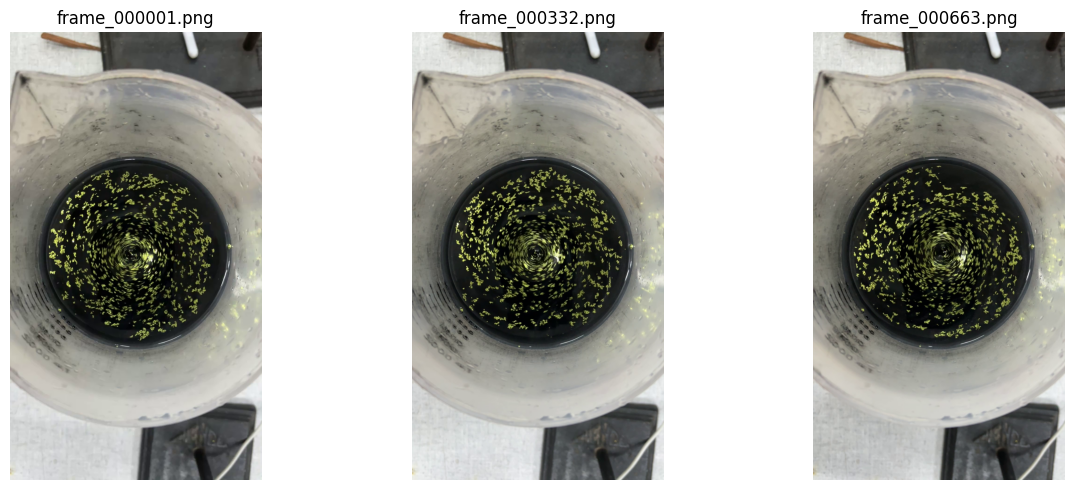

In [4]:
# Comprobación visual: primer frame, uno intermedio y último frame

archivos_frames = sorted(
    CARPETA_FRAMES.glob("frame_*.png")
)

if len(archivos_frames) == 0:
    raise RuntimeError("No encontré frames en la carpeta.")

indices = [
    0,
    len(archivos_frames) // 2,
    len(archivos_frames) - 1,
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, idx in zip(axes, indices):
    img = cv2.imread(str(archivos_frames[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(archivos_frames[idx].name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Ahora: PIVlab

Con la carpeta `video4_glicerina20_frames`:

- importá la secuencia de PNG en PIVlab;
- aplicá la máscara/ROI;
- hacé el análisis y la validación de vectores;
- guardá/exportá el resultado como `.mat`.

Después volvés acá.

La conversión de desplazamiento a velocidad usa

\[
\Delta t = \frac{\Delta N}{f_{\mathrm{fps}}},
\]

donde \(\Delta N\) es la separación entre las dos imágenes que forman cada par PIV. Si correlacionás frames consecutivos, \(\Delta N=1\).

# 2. Cargar el `.mat` de PIVlab

En tu análisis anterior, `resultslist` estaba organizado de forma que:

- columna 0: \(x\);
- columna 1: \(y\);
- columna 6: \(u\);
- columna 7: \(v\).

El notebook deja esos valores como predeterminados, pero están todos juntos en la próxima celda para poder cambiarlos si tu export nuevo fuese diferente.

In [5]:
# ============================================================
# CONFIGURACIÓN DEL RESULTADO DE PIVLAB
# ============================================================

ARCHIVO_MAT = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video4_glicerina20_PIV.mat"
)

# Columnas de resultslist, numeradas desde 0.
COL_X = 0
COL_Y = 1
COL_U = 6
COL_V = 7

# Separación ENTRE LAS DOS IMÁGENES de cada correlación PIV.
# Si usaste frames consecutivos: 1.
SALTO_DENTRO_DEL_PAR_PIV = 1

# Separación temporal entre el comienzo de dos campos PIV sucesivos.
# Ejemplos:
#   pares 1-2, 2-3, 3-4, ...  -> 1
#   pares 1-2, 3-4, 5-6, ...  -> 2
PASO_ENTRE_CAMPOS_PIV = 1

dt_piv = SALTO_DENTRO_DEL_PAR_PIV / fps

print(f"FPS = {fps:.6f}")
print(f"Δt usado para convertir desplazamiento a velocidad = {dt_piv*1000:.4f} ms")

FPS = 59.927689
Δt usado para convertir desplazamiento a velocidad = 16.6868 ms


In [6]:
def _leer_celda_hdf5(f, results, frame, columna):
    """
    Lee una celda de resultslist para un MAT v7.3 (HDF5).
    """
    ref = results[frame, columna]
    return np.array(f[ref]).T


def cargar_pivlab_mat(
    archivo,
    col_x=0,
    col_y=1,
    col_u=6,
    col_v=7,
):
    """
    Carga un resultslist de PIVlab.

    Soporta MAT v7.3/HDF5 y MAT clásico.
    """

    archivo = Path(archivo)

    if not archivo.exists():
        raise FileNotFoundError(
            "Todavía no encontré el .mat.\n"
            "Después de exportar desde PIVlab, corregí ARCHIVO_MAT."
        )

    if h5py.is_hdf5(str(archivo)):

        with h5py.File(archivo, "r") as f:

            print("Claves del MAT:")
            print(list(f.keys()))

            if "resultslist" not in f:
                raise KeyError(
                    "El archivo no contiene 'resultslist'."
                )

            results = f["resultslist"]

            print("\nresultslist.shape =", results.shape)

            n_campos = results.shape[0]

            x = _leer_celda_hdf5(f, results, 0, col_x)
            y = _leer_celda_hdf5(f, results, 0, col_y)

            campos_u = []
            campos_v = []

            for i in range(n_campos):

                campos_u.append(
                    _leer_celda_hdf5(
                        f, results, i, col_u
                    )
                )

                campos_v.append(
                    _leer_celda_hdf5(
                        f, results, i, col_v
                    )
                )

    else:

        datos = loadmat(
            archivo,
            squeeze_me=False,
            struct_as_record=False,
        )

        print("Claves del MAT:")
        print(
            [
                k for k in datos.keys()
                if not k.startswith("__")
            ]
        )

        if "resultslist" not in datos:
            raise KeyError(
                "El archivo no contiene 'resultslist'."
            )

        results = datos["resultslist"]

        print("\nresultslist.shape =", results.shape)

        n_campos = results.shape[0]

        x = np.asarray(
            results[0, col_x],
            dtype=float,
        )

        y = np.asarray(
            results[0, col_y],
            dtype=float,
        )

        campos_u = [
            np.asarray(
                results[i, col_u],
                dtype=float,
            )
            for i in range(n_campos)
        ]

        campos_v = [
            np.asarray(
                results[i, col_v],
                dtype=float,
            )
            for i in range(n_campos)
        ]

    u = np.stack(campos_u)
    v = np.stack(campos_v)

    if x.shape != y.shape:
        raise ValueError("x e y no tienen la misma forma.")

    if u.shape[1:] != x.shape or v.shape[1:] != x.shape:
        raise ValueError(
            "La forma de u/v no coincide con la grilla x/y. "
            "Revisá COL_X, COL_Y, COL_U y COL_V."
        )

    return x, y, u, v


x, y, u, v = cargar_pivlab_mat(
    ARCHIVO_MAT,
    COL_X,
    COL_Y,
    COL_U,
    COL_V,
)

n_campos = u.shape[0]

print("\nNúmero de campos:", n_campos)
print("Grilla:", x.shape)
print("u:", u.shape)
print("v:", v.shape)

Claves del MAT:
['#refs#', '#subsystem#', 'Autolimit', 'CorrQuality_nr', 'FileName', 'PIVver', 'PathName', 'add_header', 'addfileinfo', 'algorithm_selection', 'alreadydisplayed', 'alreadydisplayed_warning_uncertainty', 'autoscale_vec', 'batchModeActive', 'bg_img_A', 'bg_img_B', 'bg_mode', 'bright_filter_thresh', 'calib_boardtype', 'calib_checkersize', 'calib_columns', 'calib_dolivedetect', 'calib_markersize', 'calib_origincolor', 'calib_rows', 'calib_upscale', 'calib_use_tilted_model', 'calib_usecalibration', 'calib_userectification', 'calib_viewtype', 'caliimg', 'calu', 'calv', 'calxy', 'cam_K_opencv', 'cam_tilted_D', 'cam_use_calibration', 'cam_use_rectification', 'cam_use_tilted_model', 'cameraParams', 'cancel', 'clahe_enable', 'clahe_size', 'colormap_choice', 'colormap_interpolation', 'colormap_steps', 'contrast_filter_thresh', 'corr_filter_thresh', 'darkmode', 'delimiter', 'deriv_color_idx', 'derived', 'displacement_only', 'displaywhat', 'do_bright_filter', 'do_contrast_filter', '

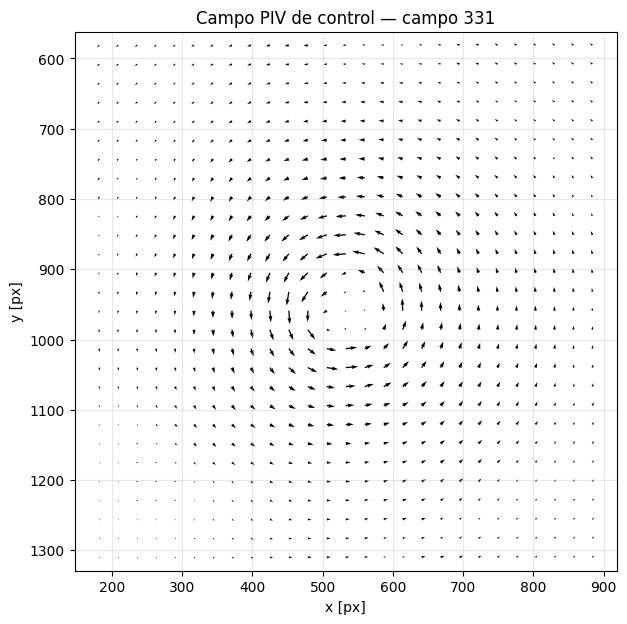

In [10]:
plt.figure(figsize=(7, 7))

plt.quiver(
    x,
    y,
    U,
    V,
    angles="xy",
    scale_units="xy",
    scale=1,
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.xlabel("x [px]")
plt.ylabel("y [px]")
plt.title(f"Campo PIV de control — campo {i_muestra}")

plt.show()

# 3. Seguir el centro del vórtice

Para un flujo principalmente azimutal, si \((x_c,y_c)\) es el centro, el vector radial y la velocidad son aproximadamente perpendiculares:

\[
(x-x_c)u+(y-y_c)v \approx 0.
\]

El estimador minimiza la componente radial normalizada,

\[
\varepsilon =
\frac{(x-x_c)u+(y-y_c)v}
{r\,|\mathbf{v}|},
\]

usando una pérdida robusta para que unos pocos vectores malos no dominen el ajuste.

Esto no supone que \(v_r\) sea exactamente cero: es un estimador geométrico del núcleo que funciona mejor cuando la componente tangencial domina. Por eso, más abajo también se comprueba cuánto cambia el perfil radial si se usa centro móvil o centro fijo.

In [11]:
# ============================================================
# PARÁMETROS DEL BUSCADOR DE CENTRO
# ============================================================

PERCENTIL_VELOCIDAD_BAJA = 20
PERCENTIL_VELOCIDAD_ALTA = 99.5

# Corona automática, expresada como cuantiles de distancia
# respecto del centro inicial.
CUANTIL_RMIN = 0.10
CUANTIL_RMAX = 0.55

# Mediana temporal para estabilizar el estimador del centro.
# Debe ser impar.
VENTANA_MEDIANA_CENTRO = 3

if VENTANA_MEDIANA_CENTRO % 2 == 0:
    raise ValueError("VENTANA_MEDIANA_CENTRO debe ser impar.")

In [12]:
def encontrar_centro(
    x,
    y,
    U,
    V,
    centro_aprox=None,
    percentil_bajo=20,
    percentil_alto=99.5,
    q_rmin=0.10,
    q_rmax=0.55,
):
    """
    Busca el centro que hace al campo lo más tangencial posible.
    """

    velocidad = np.sqrt(U**2 + V**2)

    validos = (
        np.isfinite(U)
        & np.isfinite(V)
        & np.isfinite(x)
        & np.isfinite(y)
    )

    if np.count_nonzero(validos) < 10:
        return np.array([np.nan, np.nan])

    vmin = np.nanpercentile(
        velocidad[validos],
        percentil_bajo,
    )

    vmax = np.nanpercentile(
        velocidad[validos],
        percentil_alto,
    )

    usar = (
        validos
        & (velocidad > vmin)
        & (velocidad < vmax)
    )

    if np.count_nonzero(usar) < 10:
        usar = validos.copy()

    if centro_aprox is None or not np.all(np.isfinite(centro_aprox)):

        A = np.column_stack([
            U[usar],
            V[usar],
        ])

        b = (
            U[usar] * x[usar]
            + V[usar] * y[usar]
        )

        centro_aprox, *_ = np.linalg.lstsq(
            A,
            b,
            rcond=None,
        )

    xc0, yc0 = centro_aprox

    r0 = np.sqrt(
        (x - xc0)**2
        + (y - yc0)**2
    )

    radios_validos = r0[usar]

    if radios_validos.size < 10:
        return np.asarray(centro_aprox, dtype=float)

    rmin = np.nanquantile(
        radios_validos,
        q_rmin,
    )

    rmax = np.nanquantile(
        radios_validos,
        q_rmax,
    )

    usar_corona = (
        usar
        & (r0 >= rmin)
        & (r0 <= rmax)
    )

    if np.count_nonzero(usar_corona) < 10:
        usar_corona = usar

    X = x[usar_corona]
    Y = y[usar_corona]
    UU = U[usar_corona]
    VV = V[usar_corona]

    M = np.sqrt(UU**2 + VV**2)

    def residuos(centro):
        xc, yc = centro

        dx = X - xc
        dy = Y - yc

        r = np.sqrt(
            dx**2 + dy**2
        )

        return (
            dx * UU + dy * VV
        ) / (
            r * M + 1e-12
        )

    xmin = np.nanmin(x[validos])
    xmax = np.nanmax(x[validos])
    ymin = np.nanmin(y[validos])
    ymax = np.nanmax(y[validos])

    resultado = least_squares(
        residuos,
        x0=np.asarray(centro_aprox, dtype=float),
        bounds=(
            [xmin, ymin],
            [xmax, ymax],
        ),
        loss="soft_l1",
    )

    return resultado.x

In [13]:
# Seguimiento del centro a lo largo de toda la medición

centros = np.full(
    (n_campos, 2),
    np.nan,
    dtype=float,
)

mitad_ventana = VENTANA_MEDIANA_CENTRO // 2
centro_anterior = None

for i in range(n_campos):

    i0 = max(
        0,
        i - mitad_ventana,
    )

    i1 = min(
        n_campos,
        i + mitad_ventana + 1,
    )

    U_med = np.nanmedian(
        u[i0:i1],
        axis=0,
    )

    V_med = np.nanmedian(
        v[i0:i1],
        axis=0,
    )

    centro_i = encontrar_centro(
        x,
        y,
        U_med,
        V_med,
        centro_aprox=centro_anterior,
        percentil_bajo=PERCENTIL_VELOCIDAD_BAJA,
        percentil_alto=PERCENTIL_VELOCIDAD_ALTA,
        q_rmin=CUANTIL_RMIN,
        q_rmax=CUANTIL_RMAX,
    )

    centros[i] = centro_i

    if np.all(np.isfinite(centro_i)):
        centro_anterior = centro_i

    if (i + 1) % 100 == 0:
        print(f"Centros calculados: {i+1}/{n_campos}")

xc_t = centros[:, 0]
yc_t = centros[:, 1]

print("Listo.")

Centros calculados: 100/662
Centros calculados: 200/662
Centros calculados: 300/662
Centros calculados: 400/662
Centros calculados: 500/662
Centros calculados: 600/662
Listo.


In [14]:
def mad(a):
    """
    Median Absolute Deviation escalada.
    """
    a = np.asarray(a, dtype=float)
    med = np.nanmedian(a)
    return 1.4826 * np.nanmedian(np.abs(a - med))


xc_med = np.nanmedian(xc_t)
yc_med = np.nanmedian(yc_t)

dist_prelim = np.sqrt(
    (xc_t - xc_med)**2
    + (yc_t - yc_med)**2
)

mad_dist = mad(dist_prelim)

if np.isfinite(mad_dist) and mad_dist > 0:
    limite_outlier = (
        np.nanmedian(dist_prelim)
        + 4 * mad_dist
    )

    centro_valido = (
        np.isfinite(xc_t)
        & np.isfinite(yc_t)
        & (dist_prelim <= limite_outlier)
    )
else:
    centro_valido = (
        np.isfinite(xc_t)
        & np.isfinite(yc_t)
    )

xc_fijo = np.nanmean(xc_t[centro_valido])
yc_fijo = np.nanmean(yc_t[centro_valido])

desplazamiento_centro_px = np.sqrt(
    (xc_t - xc_fijo)**2
    + (yc_t - yc_fijo)**2
)

print("Centro fijo estimado:")
print(f"xc = {xc_fijo:.3f} px")
print(f"yc = {yc_fijo:.3f} px")

print()
print(
    "Estimaciones de centro descartadas como outlier:",
    np.count_nonzero(~centro_valido),
)

Centro fijo estimado:
xc = 543.800 px
yc = 953.456 px

Estimaciones de centro descartadas como outlier: 0


In [15]:
def espaciamiento_grilla_piv(x, y):
    """
    Estima el espaciamiento típico entre vectores de la grilla PIV.
    """

    diferencias = []

    for arr in (x, y):

        if arr.shape[1] > 1:
            d = np.abs(np.diff(arr, axis=1))
            d = d[np.isfinite(d) & (d > 0)]
            diferencias.extend(d.tolist())

        if arr.shape[0] > 1:
            d = np.abs(np.diff(arr, axis=0))
            d = d[np.isfinite(d) & (d > 0)]
            diferencias.extend(d.tolist())

    if len(diferencias) == 0:
        return np.nan

    return float(np.nanmedian(diferencias))


paso_grilla_px = espaciamiento_grilla_piv(x, y)

d = desplazamiento_centro_px[centro_valido]

media_d_px = np.nanmean(d)
rms_d_px = np.sqrt(np.nanmean(d**2))
p95_d_px = np.nanpercentile(d, 95)
max_d_px = np.nanmax(d)

print(f"Espaciamiento típico de la grilla PIV: {paso_grilla_px:.3f} px")
print()
print(f"Desplazamiento medio del centro: {media_d_px:.3f} px")
print(f"RMS del desplazamiento: {rms_d_px:.3f} px")
print(f"Percentil 95: {p95_d_px:.3f} px")
print(f"Máximo: {max_d_px:.3f} px")

if np.isfinite(paso_grilla_px) and paso_grilla_px > 0:
    print()
    print(
        "p95 / paso de grilla = "
        f"{p95_d_px/paso_grilla_px:.3f}"
    )

Espaciamiento típico de la grilla PIV: 27.000 px

Desplazamiento medio del centro: 9.510 px
RMS del desplazamiento: 10.783 px
Percentil 95: 18.999 px
Máximo: 26.605 px

p95 / paso de grilla = 0.704


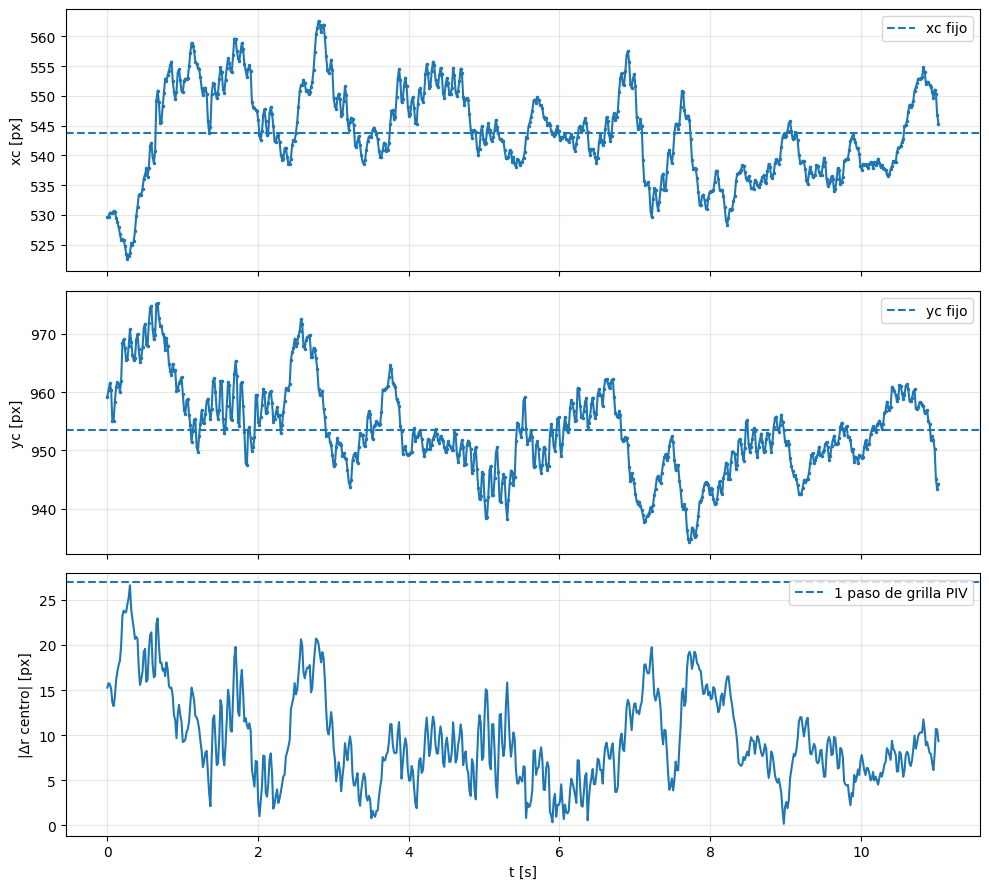

In [16]:
t_campos = (
    np.arange(n_campos)
    * PASO_ENTRE_CAMPOS_PIV
    / fps
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    t_campos,
    xc_t,
    ".-",
    markersize=3,
)

axes[0].axhline(
    xc_fijo,
    linestyle="--",
    label="xc fijo",
)

axes[0].set_ylabel("xc [px]")
axes[0].legend()

axes[1].plot(
    t_campos,
    yc_t,
    ".-",
    markersize=3,
)

axes[1].axhline(
    yc_fijo,
    linestyle="--",
    label="yc fijo",
)

axes[1].set_ylabel("yc [px]")
axes[1].legend()

axes[2].plot(
    t_campos,
    desplazamiento_centro_px,
)

if np.isfinite(paso_grilla_px):
    axes[2].axhline(
        paso_grilla_px,
        linestyle="--",
        label="1 paso de grilla PIV",
    )

axes[2].set_xlabel("t [s]")
axes[2].set_ylabel("|Δr centro| [px]")
axes[2].legend()

plt.tight_layout()
plt.show()

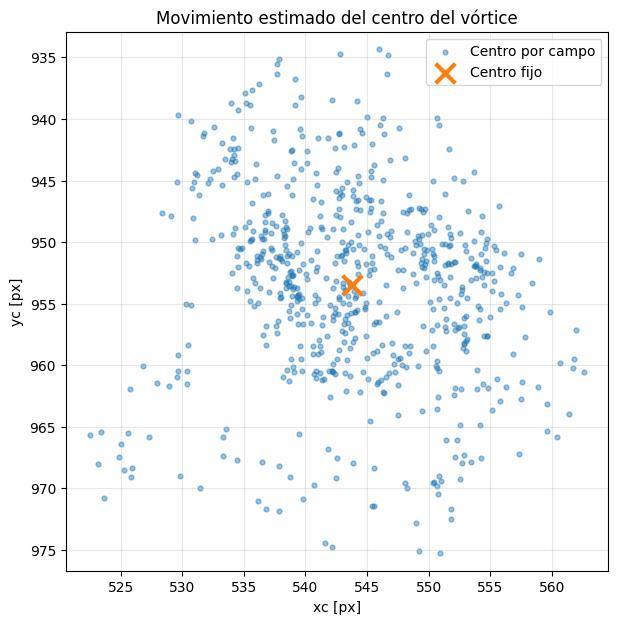

In [17]:
plt.figure(figsize=(7, 7))

plt.scatter(
    xc_t[centro_valido],
    yc_t[centro_valido],
    s=12,
    alpha=0.45,
    label="Centro por campo",
)

if np.any(~centro_valido):
    plt.scatter(
        xc_t[~centro_valido],
        yc_t[~centro_valido],
        marker="x",
        s=30,
        label="Estimación descartada",
    )

plt.scatter(
    [xc_fijo],
    [yc_fijo],
    marker="x",
    s=200,
    linewidths=3,
    label="Centro fijo",
)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.xlabel("xc [px]")
plt.ylabel("yc [px]")
plt.title("Movimiento estimado del centro del vórtice")
plt.legend()
plt.show()

## Primer criterio de estacionariedad del centro

Como criterio **operativo**, no como una ley física, se compara el movimiento del centro con la resolución espacial del campo PIV.

Un centro que se desplaza mucho menos que la separación entre vectores de la grilla no puede resolverse con gran precisión mediante ese mismo campo.

Más abajo se hace una prueba todavía más importante: comparar el perfil obtenido usando centro fijo contra el que se obtiene permitiendo un centro diferente en cada campo.

In [18]:
UMBRAL_P95_EN_PASOS_DE_GRILLA = 0.75

if np.isfinite(paso_grilla_px) and paso_grilla_px > 0:

    criterio_geometrico = (
        p95_d_px
        <= UMBRAL_P95_EN_PASOS_DE_GRILLA * paso_grilla_px
    )

    print(
        "Criterio geométrico:",
        "CUMPLE" if criterio_geometrico else "NO CUMPLE",
    )

    print(
        f"Se exige p95 <= "
        f"{UMBRAL_P95_EN_PASOS_DE_GRILLA:.2f} "
        "pasos de grilla."
    )

else:
    criterio_geometrico = None

    print(
        "No pude estimar el paso de la grilla; "
        "se decidirá con la comparación de perfiles."
    )

Criterio geométrico: CUMPLE
Se exige p95 <= 0.75 pasos de grilla.


# 4. Componentes radial y tangencial

En las imágenes, \(y\) crece hacia abajo. Para las componentes físicas se invierte ese eje, de modo que el sistema cartesiano usado tenga \(y\) hacia arriba.

Si el `.mat` contiene desplazamientos en píxeles por par de imágenes, entonces:

\[
v_x = \frac{\Delta x}{\Delta t},
\qquad
v_y = \frac{\Delta y}{\Delta t}.
\]

Si además cargás una calibración espacial, el resultado sale en mm/s. Si todavía no la tenés, el notebook funciona en px/s.

In [21]:
# ============================================================
# CALIBRACIÓN ESPACIAL
# ============================================================

DISTANCIA_PX = 1523.0
DISTANCIA_MM = 147.0

# Factor de conversión
escala_longitud = DISTANCIA_MM / DISTANCIA_PX

unidad_r = "mm"
unidad_v = "mm/s"

print(f"Escala = {escala_longitud:.6f} mm/px")
print(f"1 px = {escala_longitud:.6f} mm")

if (
    DISTANCIA_PX is not None
    and DISTANCIA_MM is not None
):
    escala_longitud = (
        float(DISTANCIA_MM)
        / float(DISTANCIA_PX)
    )

    unidad_r = "mm"
    unidad_v = "mm/s"

else:
    escala_longitud = 1.0
    unidad_r = "px"
    unidad_v = "px/s"

    print(
        "AVISO: no cargaste calibración espacial. "
        "El análisis se hará en px y px/s."
    )

print("Escala de longitud:", escala_longitud, unidad_r + "/px")

Escala = 0.096520 mm/px
1 px = 0.096520 mm
Escala de longitud: 0.09652002626395273 mm/px


In [22]:
def componentes_polares(
    x,
    y,
    U,
    V,
    xc,
    yc,
    escala_longitud,
    dt,
):
    """
    U y V se interpretan como desplazamientos en píxeles
    entre las dos imágenes correlacionadas por PIVlab.
    """

    dx = x - xc
    dy = -(y - yc)

    r_px = np.sqrt(
        dx**2 + dy**2
    )

    r = (
        r_px * escala_longitud
    )

    ux = (
        U * escala_longitud / dt
    )

    uy = (
        -V * escala_longitud / dt
    )

    er_x = np.divide(
        dx,
        r_px,
        out=np.full_like(dx, np.nan, dtype=float),
        where=r_px > 0,
    )

    er_y = np.divide(
        dy,
        r_px,
        out=np.full_like(dy, np.nan, dtype=float),
        where=r_px > 0,
    )

    et_x = -er_y
    et_y = er_x

    vr = (
        ux * er_x
        + uy * er_y
    )

    vtheta = (
        ux * et_x
        + uy * et_y
    )

    return r, vr, vtheta

In [23]:
def perfil_radial(
    r,
    valor,
    bins,
    minimo_vectores=3,
):
    """
    Promedia espacialmente todos los vectores que caen
    dentro de una misma corona radial.
    """

    perfil = np.full(
        len(bins) - 1,
        np.nan,
        dtype=float,
    )

    cantidad = np.zeros(
        len(bins) - 1,
        dtype=int,
    )

    for k in range(len(bins) - 1):

        dentro = (
            np.isfinite(r)
            & np.isfinite(valor)
            & (r >= bins[k])
            & (r < bins[k + 1])
        )

        cantidad[k] = np.count_nonzero(dentro)

        if cantidad[k] >= minimo_vectores:
            perfil[k] = np.nanmean(
                valor[dentro]
            )

    return perfil, cantidad

In [24]:
# ============================================================
# CORONAS RADIALES
# ============================================================

if unidad_r == "px":

    if np.isfinite(paso_grilla_px):
        DR = max(1.0, paso_grilla_px / 4)
    else:
        DR = 5.0

else:
    DR = 1.0  # mm


r_grilla_px = np.sqrt(
    (x - xc_fijo)**2
    + (y - yc_fijo)**2
)

mascara_ref = (
    np.isfinite(u[0])
    & np.isfinite(v[0])
)

r_max_disponible = (
    np.nanpercentile(
        r_grilla_px[mascara_ref],
        95,
    )
    * escala_longitud
)

bins = np.arange(
    0,
    r_max_disponible + DR,
    DR,
)

r_centros = 0.5 * (
    bins[:-1]
    + bins[1:]
)

print(f"Ancho de corona DR = {DR:.3f} {unidad_r}")
print(f"Radio máximo analizado ≈ {r_max_disponible:.3f} {unidad_r}")

Ancho de corona DR = 1.000 mm
Radio máximo analizado ≈ 43.005 mm


## Prueba directa: centro fijo vs centro móvil

Este es el chequeo más importante para decidir si fijar el centro altera los resultados.

Para cada campo se calculan dos perfiles:

- uno usando siempre \((x_c,y_c)=(\bar x_c,\bar y_c)\);
- otro usando \((x_c(t),y_c(t))\).

Luego se compara el perfil tangencial promedio de ambos casos.

In [25]:
perfiles_theta_fijo = []
perfiles_r_fijo = []

perfiles_theta_movil = []
perfiles_r_movil = []

for i in range(n_campos):

    r_f, vr_f, vt_f = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_fijo,
        yc_fijo,
        escala_longitud,
        dt_piv,
    )

    p_vt_f, _ = perfil_radial(
        r_f,
        vt_f,
        bins,
    )

    p_vr_f, _ = perfil_radial(
        r_f,
        vr_f,
        bins,
    )

    perfiles_theta_fijo.append(p_vt_f)
    perfiles_r_fijo.append(p_vr_f)

    if (
        np.isfinite(xc_t[i])
        and np.isfinite(yc_t[i])
    ):
        xc_i = xc_t[i]
        yc_i = yc_t[i]
    else:
        xc_i = xc_fijo
        yc_i = yc_fijo

    r_m, vr_m, vt_m = componentes_polares(
        x,
        y,
        u[i],
        v[i],
        xc_i,
        yc_i,
        escala_longitud,
        dt_piv,
    )

    p_vt_m, _ = perfil_radial(
        r_m,
        vt_m,
        bins,
    )

    p_vr_m, _ = perfil_radial(
        r_m,
        vr_m,
        bins,
    )

    perfiles_theta_movil.append(p_vt_m)
    perfiles_r_movil.append(p_vr_m)


perfiles_theta_fijo = np.asarray(perfiles_theta_fijo)
perfiles_r_fijo = np.asarray(perfiles_r_fijo)

perfiles_theta_movil = np.asarray(perfiles_theta_movil)
perfiles_r_movil = np.asarray(perfiles_r_movil)

In [26]:
def estadistica_temporal(perfiles):
    """
    Para cada corona devuelve:
    media temporal, desviación estándar, SEM y cantidad de campos.
    """

    perfiles = np.asarray(
        perfiles,
        dtype=float,
    )

    n = np.sum(
        np.isfinite(perfiles),
        axis=0,
    )

    media = np.divide(
        np.nansum(perfiles, axis=0),
        n,
        out=np.full(
            perfiles.shape[1],
            np.nan,
            dtype=float,
        ),
        where=n > 0,
    )

    std = np.full_like(
        media,
        np.nan,
        dtype=float,
    )

    for k in range(perfiles.shape[1]):

        vals = perfiles[:, k]
        vals = vals[np.isfinite(vals)]

        if len(vals) >= 2:
            std[k] = np.std(
                vals,
                ddof=1,
            )

    sem = np.divide(
        std,
        np.sqrt(n),
        out=np.full_like(std, np.nan),
        where=n > 0,
    )

    return media, std, sem, n


vt_fijo, vt_fijo_std, vt_fijo_sem, n_vt_fijo = (
    estadistica_temporal(
        perfiles_theta_fijo
    )
)

vr_fijo, vr_fijo_std, vr_fijo_sem, n_vr_fijo = (
    estadistica_temporal(
        perfiles_r_fijo
    )
)

vt_movil, vt_movil_std, vt_movil_sem, n_vt_movil = (
    estadistica_temporal(
        perfiles_theta_movil
    )
)

vr_movil, vr_movil_std, vr_movil_sem, n_vr_movil = (
    estadistica_temporal(
        perfiles_r_movil
    )
)

In [27]:
validos_comparacion = (
    np.isfinite(vt_fijo)
    & np.isfinite(vt_movil)
)

if np.any(validos_comparacion):

    escala_v = np.nanmax(
        np.abs(
            vt_movil[validos_comparacion]
        )
    )

    rmse_perfiles = np.sqrt(
        np.nanmean(
            (
                vt_fijo[validos_comparacion]
                - vt_movil[validos_comparacion]
            )**2
        )
    )

    if escala_v > 0:
        nrmse_perfiles = (
            rmse_perfiles / escala_v
        )
    else:
        nrmse_perfiles = np.nan

else:
    nrmse_perfiles = np.nan


UMBRAL_CAMBIO_PERFIL = 0.05

criterio_perfiles = (
    np.isfinite(nrmse_perfiles)
    and nrmse_perfiles <= UMBRAL_CAMBIO_PERFIL
)

print(
    "Diferencia fija vs móvil (NRMSE):",
    f"{100*nrmse_perfiles:.2f} %"
    if np.isfinite(nrmse_perfiles)
    else "no disponible",
)

print(
    "Criterio por perfiles:",
    "CUMPLE" if criterio_perfiles else "NO CUMPLE",
)

Diferencia fija vs móvil (NRMSE): 1.20 %
Criterio por perfiles: CUMPLE


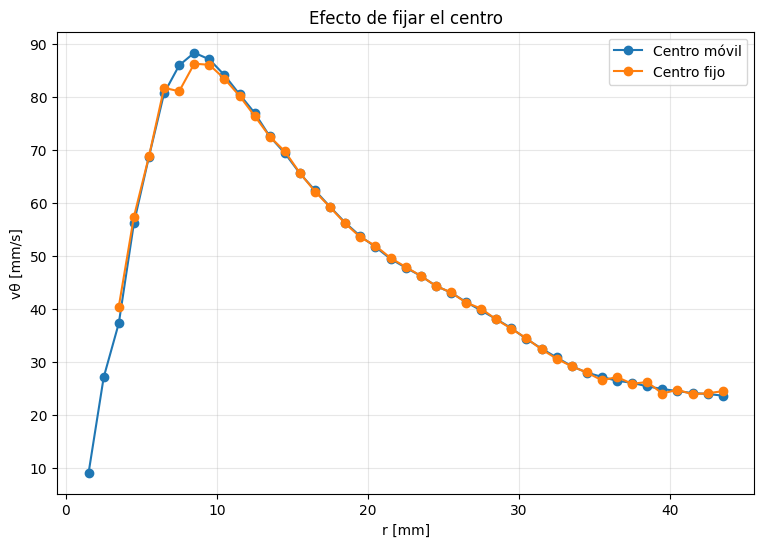

In [28]:
plt.figure(figsize=(9, 6))

plt.plot(
    r_centros,
    vt_movil,
    "o-",
    label="Centro móvil",
)

plt.plot(
    r_centros,
    vt_fijo,
    "o-",
    label="Centro fijo",
)

plt.xlabel(f"r [{unidad_r}]")
plt.ylabel(f"vθ [{unidad_v}]")
plt.title("Efecto de fijar el centro")
plt.legend()
plt.show()

# 5. Decisión: ¿puedo considerar fijo el centro?

La decisión combina dos ideas:

1. que el movimiento aparente del centro sea pequeño frente a la resolución espacial de la grilla PIV;
2. que usar centro fijo no modifique apreciablemente el perfil \(v_\theta(r)\).

Los umbrales son criterios de trabajo, no leyes universales, y están escritos explícitamente arriba para poder modificarlos.

In [29]:
if criterio_geometrico is None:
    centro_practicamente_fijo = (
        criterio_perfiles
    )
else:
    centro_practicamente_fijo = (
        criterio_geometrico
        and criterio_perfiles
    )


print("=" * 65)

if centro_practicamente_fijo:

    print("RESULTADO: EL CENTRO PUEDE TRATARSE COMO PRÁCTICAMENTE FIJO.")
    print()
    print(
        f"(xc, yc) = ({xc_fijo:.3f}, {yc_fijo:.3f}) px"
    )

else:

    print("RESULTADO: NO CONVIENE ASUMIR TODAVÍA UN CENTRO FIJO.")
    print()
    print(
        "Mirá xc(t), yc(t), el desplazamiento y "
        "la comparación centro fijo/móvil antes de seguir."
    )

print("=" * 65)

RESULTADO: EL CENTRO PUEDE TRATARSE COMO PRÁCTICAMENTE FIJO.

(xc, yc) = (543.800, 953.456) px


# 6. Análisis final usando centro fijo

Esta sección se ejecuta solamente si la celda anterior concluye que el centro fijo es una aproximación razonable.

Primero se promedia temporalmente el **campo cartesiano completo**. Después se muestran los perfiles \(v_r(r)\) y \(v_\theta(r)\), obtenidos mediante promedio espacial en coronas y luego promedio temporal.

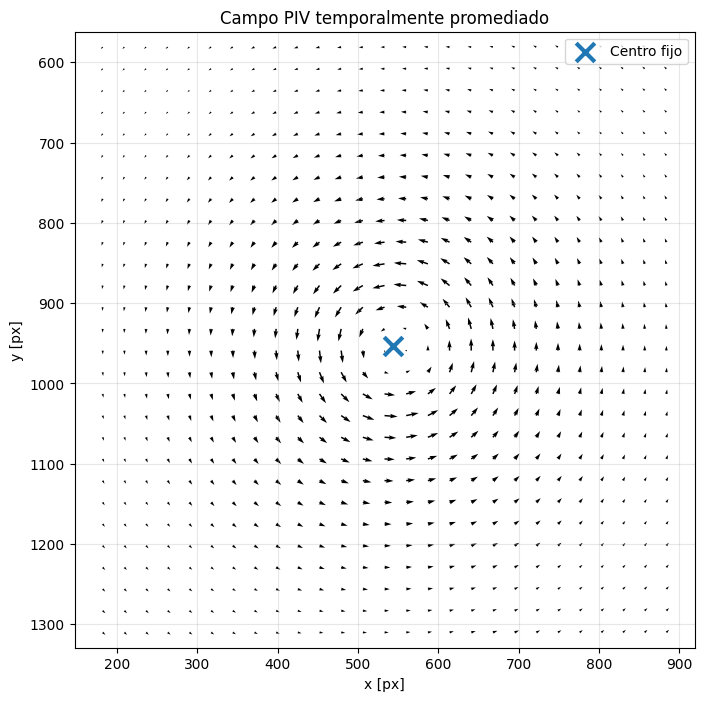

In [35]:
if not centro_practicamente_fijo:
    raise RuntimeError(
        "El criterio automático NO recomienda usar centro fijo. "
        "Revisá primero la sección 5."
    )

u_prom = np.nanmean(
    u,
    axis=0,
)

v_prom = np.nanmean(
    v,
    axis=0,
)

plt.figure(figsize=(8, 8))

plt.quiver(
    x,
    y,
    u_prom,
    v_prom,
    angles="xy",
    scale_units="xy",
    scale=1,
)

plt.scatter(
    [xc_fijo],
    [yc_fijo],
    marker="x",
    s=180,
    linewidths=3,
    label="Centro fijo",
)

plt.gca().invert_yaxis()

plt.axis("equal")

plt.xlabel("x [px]")
plt.ylabel("y [px]")

plt.title("Campo PIV temporalmente promediado")

plt.legend()
plt.show()

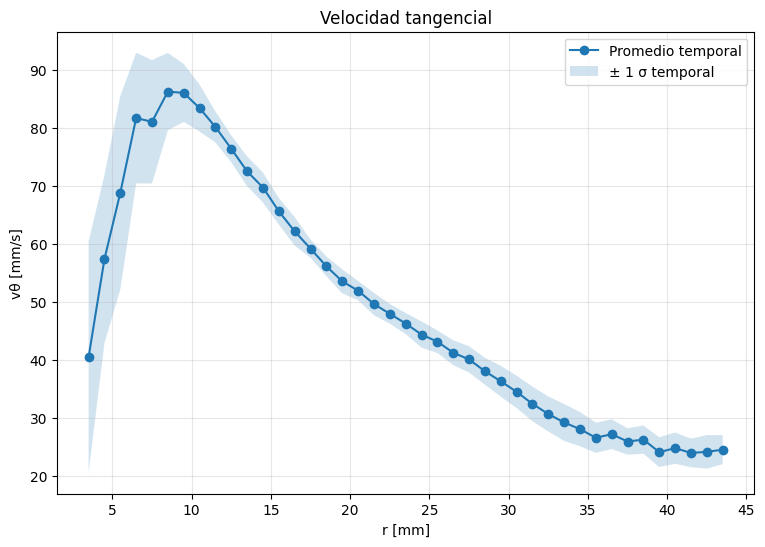

In [31]:
plt.figure(figsize=(9, 6))

plt.plot(
    r_centros,
    vt_fijo,
    "o-",
    label="Promedio temporal",
)

plt.fill_between(
    r_centros,
    vt_fijo - vt_fijo_std,
    vt_fijo + vt_fijo_std,
    alpha=0.2,
    label="± 1 σ temporal",
)

plt.xlabel(f"r [{unidad_r}]")
plt.ylabel(f"vθ [{unidad_v}]")
plt.title("Velocidad tangencial")
plt.legend()
plt.show()

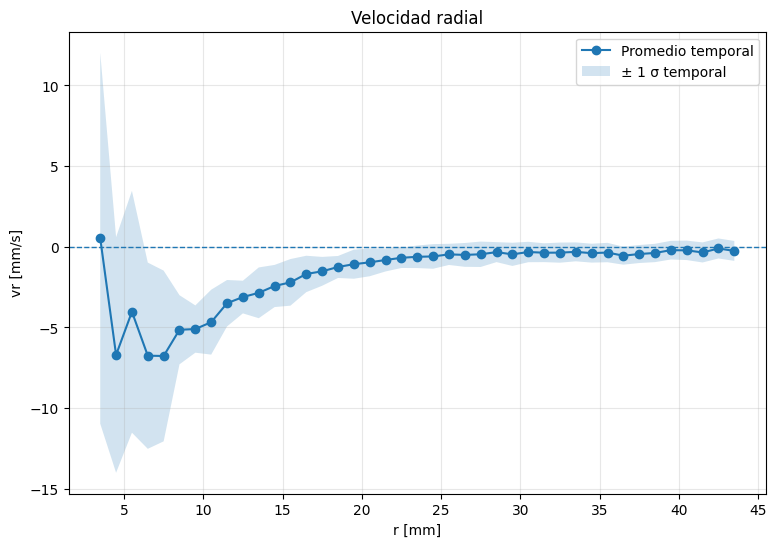

In [32]:
plt.figure(figsize=(9, 6))

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.plot(
    r_centros,
    vr_fijo,
    "o-",
    label="Promedio temporal",
)

plt.fill_between(
    r_centros,
    vr_fijo - vr_fijo_std,
    vr_fijo + vr_fijo_std,
    alpha=0.2,
    label="± 1 σ temporal",
)

plt.xlabel(f"r [{unidad_r}]")
plt.ylabel(f"vr [{unidad_v}]")
plt.title("Velocidad radial")
plt.legend()
plt.show()

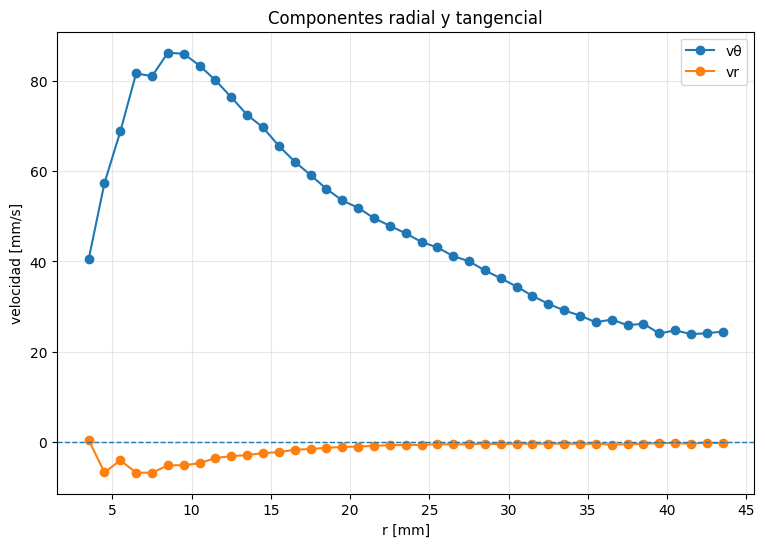

In [33]:
plt.figure(figsize=(9, 6))

plt.plot(
    r_centros,
    vt_fijo,
    "o-",
    label="vθ",
)

plt.plot(
    r_centros,
    vr_fijo,
    "o-",
    label="vr",
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel(f"r [{unidad_r}]")
plt.ylabel(f"velocidad [{unidad_v}]")
plt.title("Componentes radial y tangencial")
plt.legend()
plt.show()

## Qué significa exactamente el promedio

Para cada instante \(t_i\), primero se promedian los vectores que caen dentro de una corona radial:

\[
\bar v_\theta(r_k,t_i)
=
\frac{1}{N_{k,i}}
\sum_{j\in k} v_{\theta,j}(t_i).
\]

Luego se hace el promedio temporal de esos perfiles:

\[
\langle v_\theta(r_k)\rangle_t
=
\frac{1}{N_t}
\sum_i
\bar v_\theta(r_k,t_i).
\]

Así, cada campo temporal aporta un perfil y no se mezclan directamente todos los vectores de todos los tiempos en una sola bolsa.

La banda dibujada en las figuras es la **desviación estándar temporal**, que representa cuánto fluctúa el perfil de un instante a otro. El notebook también calcula el error estándar de la media,

\[
\mathrm{SEM}(r)
=
\frac{\sigma_t(r)}{\sqrt{N(r)}}.
\]

In [34]:
tabla_centros = pd.DataFrame(
    {
        "campo": np.arange(n_campos),
        "t_s": t_campos,
        "xc_px": xc_t,
        "yc_px": yc_t,
        "centro_valido": centro_valido,
        "desplazamiento_desde_centro_fijo_px": desplazamiento_centro_px,
    }
)

tabla_centros.to_csv(
    CARPETA_RESULTADOS / "centro_vortice.csv",
    index=False,
)


tabla_perfiles = pd.DataFrame(
    {
        f"r_{unidad_r}": r_centros,
        f"vtheta_media_{unidad_v}": vt_fijo,
        f"vtheta_std_temporal_{unidad_v}": vt_fijo_std,
        f"vtheta_sem_{unidad_v}": vt_fijo_sem,
        "n_campos_vtheta": n_vt_fijo,
        f"vr_media_{unidad_v}": vr_fijo,
        f"vr_std_temporal_{unidad_v}": vr_fijo_std,
        f"vr_sem_{unidad_v}": vr_fijo_sem,
        "n_campos_vr": n_vr_fijo,
    }
)

tabla_perfiles.to_csv(
    CARPETA_RESULTADOS / "perfiles_radiales.csv",
    index=False,
)


np.savez(
    CARPETA_RESULTADOS / "campo_promedio.npz",
    x=x,
    y=y,
    u_prom=u_prom,
    v_prom=v_prom,
    xc_fijo=xc_fijo,
    yc_fijo=yc_fijo,
)


print("Resultados guardados en:")
print(CARPETA_RESULTADOS)

print()
print("- centro_vortice.csv")
print("- perfiles_radiales.csv")
print("- campo_promedio.npz")

Resultados guardados en:
C:\Users\user\Desktop\video4_glicerina20_analisis

- centro_vortice.csv
- perfiles_radiales.csv
- campo_promedio.npz


# Resumen del flujo de trabajo

**Ahora mismo:** ejecutá hasta terminar la sección 1. Eso crea la carpeta de frames en el Escritorio.

**Después:** procesá esa secuencia en PIVlab y exportá el `.mat`.

**Finalmente:** corregí `ARCHIVO_MAT` en la sección 2 y ejecutá el resto. La sección 5 te dirá si el centro fijo es una aproximación aceptable; la sección 6 queda bloqueada automáticamente si el criterio no se cumple.